# Training and Evaluation (COUGHVID)

## Imports

In [1]:
# system imports
import os
from datetime import datetime

# additional imports
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
from torch.utils.tensorboard import SummaryWriter

# internal imports
from utils import plot_confusion_matrix, CoughNet

# device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

c:\Users\aint\anaconda3\envs\base1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters

In [2]:
hparams = {
    'dataset': 'data/prepared_train_coughvid_balanced.csv',
    'epochs': 20,
    'batch_size': 16,
    'lr': 1e-3,
    'features': [
        'chroma_stft', 'rmse', 'spectral_centroid', 'spectral_bandwidth', 'rolloff', 'zero_crossing_rate',
        'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10',
        'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20'
    ]
}

## Prepare Data

In [3]:
df = pd.read_csv(hparams['dataset'])
X  = np.array(df[hparams['features']], dtype=np.float32)

encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])
print('classes:', encoder.classes_)
print('label 分佈:')
print(df['label'].value_counts())

# 80/20 split，記錄 test indices 以便後續輸出
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'\nX_train.shape: {X_train.shape}')
print(f'X_test.shape:  {X_test.shape}')

# Scale
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# DataLoader
torch.manual_seed(42)
train_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train).long())
test_dataset  = torch.utils.data.TensorDataset(torch.Tensor(X_test),  torch.Tensor(y_test).long())
train_loader  = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=hparams['batch_size'], shuffle=True)
test_loader   = torch.utils.data.DataLoader(dataset=test_dataset,  batch_size=hparams['batch_size'], shuffle=False)

classes: ['covid' 'healthy' 'symptomatic']
label 分佈:
label
covid          470
healthy        470
symptomatic    470
Name: count, dtype: int64

X_train.shape: (1128, 26)
X_test.shape:  (282, 26)


## Setup Model

> ⚠️ 三分類：請確認 `utils.py` 的 `CoughNet` 最後一層為 `Linear(10, 3)`。

In [4]:
model = CoughNet(len(hparams['features'])).to(device)

## Training

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=hparams['lr'])
criterion = torch.nn.CrossEntropyLoss()

def train(loader_train, model, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_correct = 0.0
    total = 0
    pbar = tqdm(enumerate(loader_train), total=len(loader_train))
    for batch_ndx, sample in pbar:
        features, labels = sample[0].to(device), sample[1].to(device)
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()
        predictions = torch.argmax(outputs.data, 1)
        running_correct += (predictions == labels).sum().item()
        total += labels.shape[0]
        pbar.set_description(f'[Training Epoch {epoch+1}]')
        pbar.set_postfix({'loss': running_loss / total, 'train_accuracy': running_correct / total})
    writer.add_scalar('Loss/Train', running_loss / total, epoch+1)
    writer.add_scalar('Accuracy/Train', running_correct / total, epoch+1)

def evaluate(loader_test, model, epoch):
    model.eval()
    running_loss = 0.0
    running_correct = 0.0
    total = 0
    with torch.no_grad():
        pbar = tqdm(enumerate(loader_test), total=len(loader_test))
        for batch_ndx, sample in pbar:
            features, labels = sample[0].to(device), sample[1].to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = torch.argmax(outputs.data, 1)
            running_correct += (predictions == labels).sum().item()
            total += labels.shape[0]
            pbar.set_description(f'[Evaluating Epoch {epoch+1}]')
            pbar.set_postfix({'loss': running_loss / total, 'eval_accuracy': running_correct / total})
    writer.add_scalar('Loss/Eval', running_loss / total, epoch+1)
    writer.add_scalar('Accuracy/Eval', running_correct / total, epoch+1)

time_stamp = datetime.now().strftime('%Y%m%d-%H%M%S')
writer = SummaryWriter(f'logs/{time_stamp}/')

features_sample = next(iter(test_loader))[0].to(device)
writer.add_graph(model, features_sample)

for epoch in range(hparams['epochs']):
    train(train_loader, model, optimizer, epoch)
    evaluate(test_loader, model, epoch)

writer.close()

[Evaluating Epoch 20]: 100%|██████████| 18/18 [00:00<00:00, 801.20it/s, loss=0.137, eval_accuracy=0.415]


## Plot Confusion Matrix & Classification Report

              precision    recall  f1-score   support

       covid       0.37      0.30      0.33        94
     healthy       0.45      0.63      0.52        94
 symptomatic       0.40      0.32      0.36        94

    accuracy                           0.41       282
   macro avg       0.41      0.41      0.40       282
weighted avg       0.41      0.41      0.40       282



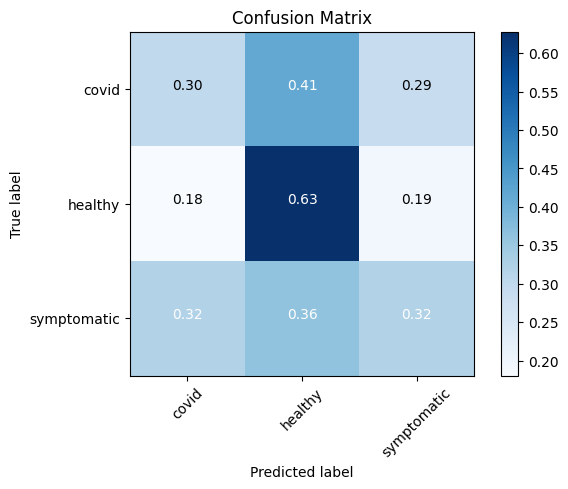

In [6]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    outputs = model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1).cpu().numpy()

plot_confusion_matrix(y_test, predictions, encoder.classes_)
print(classification_report(y_test, predictions, target_names=encoder.classes_))

## Save Checkpoint & Test Split

In [7]:
os.makedirs('checkpoints', exist_ok=True)

checkpoint = {
    'hparams':     hparams,
    'model_state': model.state_dict(),
    'scaler':      scaler,
    'encoder':     encoder
}
torch.save(checkpoint, 'checkpoints/checkpoint_coughvid.pth')
print('Checkpoint saved to checkpoints/checkpoint_coughvid.pth')

# 輸出 test split，供 003_inference 使用
df_test_split = df.iloc[test_idx].copy()
df_test_split.to_csv('data/prepared_test_split.csv', index=False)
print(f'Test split saved to data/prepared_test_split.csv ({len(df_test_split)} 筆)')
print(df_test_split['label'].value_counts())

Checkpoint saved to checkpoints/checkpoint_coughvid.pth
Test split saved to data/prepared_test_split.csv (282 筆)
label
symptomatic    94
covid          94
healthy        94
Name: count, dtype: int64
